<a href="https://colab.research.google.com/github/tanisha1402/Machine-Learning-Practice/blob/main/Projects/Face_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("anku5hk/5-faces-dataset")

print("Path to dataset files:", path)

100%|██████████| 13.1M/13.1M [00:00<00:00, 240MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/anku5hk/5-faces-dataset/versions/1


In [2]:
!cp -r "$path" /content/face_detect

**Data Prep**

In [3]:
!pip install split-folders

In [4]:
import splitfolders
splitfolders.ratio('/content/face_detect/Five_Faces', output="dataset", seed=1337, ratio=(.8, .1, .1))

Copying files: 694 files [00:00, 7754.38 files/s]


In [5]:
img_size = (160,160)
batch_size = 32
train = '/content/dataset/train'
test = '/content/dataset/val'
val = '/content/dataset/test'

In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [17]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train,
    image_size = img_size,
    batch_size=batch_size
)

Found 553 files belonging to 5 classes.


In [18]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    test,
    image_size = img_size,
    batch_size=batch_size
)

Found 67 files belonging to 5 classes.


In [19]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    val,
    image_size = img_size,
    batch_size=batch_size
)

Found 74 files belonging to 5 classes.


In [21]:
class_names = train_ds.class_names
num_classes = len(class_names)
print("classes : ",class_names)

classes :  ['gates', 'jack', 'modi', 'musk', 'trump']


In [29]:
autotune= tf.data.AUTOTUNE

In [30]:
train_ds = train_ds.map(lambda x,y: (x/255,y)).prefetch(autotune)
test_ds = test_ds.map(lambda x,y: (x/255,y)).prefetch(autotune)
val_ds = val_ds.map(lambda x,y: (x/255,y)).prefetch(autotune)

In [31]:
from tensorflow.keras import layers
from tensorflow.keras import models

In [33]:
model = models.Sequential([
        layers.Input(shape=img_size+(3,)),
        layers.Conv2D(32,3,activation='relu'),
        layers.MaxPooling2D(),

        layers.Conv2D(64,3, activation='relu'),
        layers.MaxPooling2D(),

        layers.Conv2D(128,3, activation='relu'),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ]
)

In [34]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [35]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 158, 158, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 79, 79, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 77, 77, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 36, 36, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     5,308,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,402,437 (20.61 MB)

 Trainable params: 5,402,437 (20.61 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
model.fit(train_ds, epochs=10, validation_data=val_ds)

Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 13s 304ms/step - accuracy: 0.1945 - loss: 1.8795 - val_accuracy: 0.3784 - val_loss: 1.5663
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.3449 - loss: 1.4996 - val_accuracy: 0.6216 - val_loss: 1.1565
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.5599 - loss: 1.2049 - val_accuracy: 0.5676 - val_loss: 1.0508
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.7385 - loss: 0.8761 - val_accuracy: 0.6081 - val_loss: 1.0253
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8057 - loss: 0.6166 - val_accuracy: 0.7027 - val_loss: 0.8178
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8910 - loss: 0.3263 - val_accuracy: 0.6892 - val_loss: 0.8110
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9454 - loss: 0.1969 - val_accuracy: 0.6486 - val_loss: 1.0343
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9694 - loss: 0.1293 - val_accuracy: 0.7162 -

In [37]:
loss,accuracy = model.evaluate(test_ds)
print(f"Test accuracy: {round(accuracy * 100, 2)}%")

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 421ms/step - accuracy: 0.6295 - loss: 1.7521
Test accuracy: 64.18%


In [38]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

In [45]:
img_path = '/content/dataset/test/jack/jack54.jpg'

In [46]:
img = image.load_img(img_path, target_size=img_size)
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
pred = model.predict(x)
pred_id = np.argmax(pred)
print(f"Prediction: {class_names[pred_id]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Prediction: jack


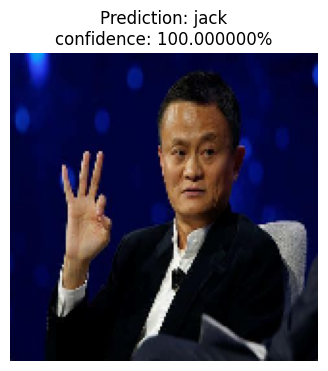

In [48]:
pred_name = class_names[pred_id]
confidence = np.max(pred[0]) * 100
plt.figure(figsize=(4,4))
plt.imshow(img)
plt.axis("off")
plt.title(f"Prediction: {pred_name}\nconfidence: {confidence:2f}%")
plt.show()